In [1]:
from pathlib import Path, PurePosixPath
import json

SPLIT_DIR = Path("data/splits_out/superglue_boolq")  # adjust if your folder name differs
sample_file = SPLIT_DIR / "N16_seed0.jsonl"
print("Exists?", sample_file.exists(), sample_file)

with sample_file.open() as f:
    row = json.loads(next(f))
row.keys(), row["x"][:120], row["y"]

Exists? True data/splits_out/superglue_boolq/N16_seed0.jsonl


(dict_keys(['id', 'x', 'y', 'label', 'meta']),
 'Passage: Buttermilk pie -- Buttermilk pie is a custard-like pie. Originally from the United Kingdom, it is now a traditi',
 'False')

In [2]:
!pip -q install -U transformers datasets accelerate torch tqdm pandas matplotlib

import os, time, json
from pathlib import Path
from typing import List, Dict, Tuple

import torch
from datasets import load_dataset
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 12.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
cudf-cu12 25.10.0 requires pandas<2.4.0dev0,>=2.0, but you have pandas 3.0.1 which 

In [3]:
ds_val = load_dataset("super_glue", "boolq", split="validation")
print(ds_val.column_names)
print(ds_val[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

boolq/train-00000-of-00001.parquet:   0%|          | 0.00/3.85M [00:00<?, ?B/s]

boolq/validation-00000-of-00001.parquet:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

boolq/test-00000-of-00001.parquet:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9427 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3270 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3245 [00:00<?, ? examples/s]

['question', 'passage', 'idx', 'label']
{'question': 'does ethanol take more energy make that produces', 'passage': "Ethanol fuel -- All biomass goes through at least some of these steps: it needs to be grown, collected, dried, fermented, distilled, and burned. All of these steps require resources and an infrastructure. The total amount of energy input into the process compared to the energy released by burning the resulting ethanol fuel is known as the energy balance (or ``energy returned on energy invested''). Figures compiled in a 2007 report by National Geographic Magazine point to modest results for corn ethanol produced in the US: one unit of fossil-fuel energy is required to create 1.3 energy units from the resulting ethanol. The energy balance for sugarcane ethanol produced in Brazil is more favorable, with one unit of fossil-fuel energy required to create 8 from the ethanol. Energy balance estimates are not easily produced, thus numerous such reports have been generated that a

In [4]:
def gold_label_boolq(row) -> str:
    if "answer" in row:  # SuperGLUE
        return "True" if bool(row["answer"]) else "False"
    if "label" in row:   # standalone BoolQ
        return "True" if int(row["label"]) == 1 else "False"
    raise KeyError(f"No BoolQ label field found. Keys: {list(row.keys())}")

In [5]:
eval_rows = [row for row in ds_val]  # you can subsample if needed
print("Eval examples:", len(eval_rows))
print("Example gold:", gold_label_boolq(eval_rows[0]))

Eval examples: 3270
Example gold: False


In [6]:
# Sanity Check
row = eval_rows[0]
print("PASSAGE:", row.get("passage","")[:200])
print("QUESTION:", row.get("question",""))
print("GOLD:", gold_label_boolq(row))

PASSAGE: Ethanol fuel -- All biomass goes through at least some of these steps: it needs to be grown, collected, dried, fermented, distilled, and burned. All of these steps require resources and an infrastruct
QUESTION: does ethanol take more energy make that produces
GOLD: False


In [7]:
from pathlib import Path
import json

SPLIT_DIR = Path("data/splits_out/superglue_boolq")
seed = 0
N = 16

split_file = SPLIT_DIR / f"N{N}_seed{seed}.jsonl"

def read_jsonl(path):
    rows = []
    with open(path, "r") as f:
        for line in f:
            rows.append(json.loads(line))
    return rows

demos = read_jsonl(split_file)
print("Loaded demos:", len(demos))
print(demos[0].keys())

Loaded demos: 16
dict_keys(['id', 'x', 'y', 'label', 'meta'])


In [8]:
def build_prompt(demos, passage, question):
    header = (
        "Task: Boolean Question Answering (BoolQ).\n"
        "Answer EXACTLY one word: True or False.\n\n"
    )

    shots = ""
    for ex in demos:
        shots += f"Input:\n{ex['x']}\nLabel: {ex['y']}\n\n"

    query = f"Passage: {passage}\nQuestion: {question}\nLabel:"

    return header + shots + query

# Test
row = eval_rows[0]
prompt = build_prompt(demos, row["passage"], row["question"])
print(prompt[:1000])

Task: Boolean Question Answering (BoolQ).
Answer EXACTLY one word: True or False.

Input:
Passage: Buttermilk pie -- Buttermilk pie is a custard-like pie. Originally from the United Kingdom, it is now a traditional pie of the southern United States. It is similar to, and sometimes confused with, chess pie but it does not include cornmeal. The basic filling consists of a mixture of sugar, butter, eggs, buttermilk and wheat flour. Variations on the recipe may include flavorings such as vanilla, lemon zest and nutmeg. Buttermilk pies are made with a pie crust. The filling is poured into the crust and baked until the mixture sets. The pie is best eaten at room temperature after being allowed to cool, but may be eaten either warm from the oven or after being chilled.
Question: are chess pie and buttermilk pie the same
Label: False

Input:
Passage: Hyundai Genesis Coupe -- The Hyundai Genesis Coupé is a rear-wheel drive sports coupe from Hyundai Motor Company, released on October 13, 2008 fo

In [10]:
# Load Qwen3-4B-Instruct

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "Qwen/Qwen3-4B-Instruct-2507"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
)
model.eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loaded:", MODEL_NAME)
print("Device:", next(model.parameters()).device)

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

Loaded: Qwen/Qwen3-4B-Instruct-2507
Device: cuda:0


In [11]:
import torch
import time

@torch.inference_mode()
def run_one(prompt):
    torch.cuda.synchronize()
    t0 = time.perf_counter()

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    prompt_tokens = inputs["input_ids"].shape[-1]

    out = model.generate(
        **inputs,
        max_new_tokens=2,
        do_sample=False,
        temperature=0.0,
        pad_token_id=tokenizer.eos_token_id,
    )

    torch.cuda.synchronize()
    t1 = time.perf_counter()

    gen_ids = out[0, inputs["input_ids"].shape[-1]:]
    text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()
    latency_ms = (t1 - t0) * 1000

    return text, prompt_tokens, latency_ms

raw_pred, prompt_len, latency = run_one(prompt)

print("Raw output:", raw_pred)
print("Prompt tokens:", prompt_len)
print("Latency ms:", latency)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Raw output: False
Prompt tokens: 2840
Latency ms: 6163.53651899999


In [13]:
def parse_pred(text):
    t = (text or "").strip().lower()
    if t.startswith("true") or " true" in t:
        return "True"
    if t.startswith("false") or " false" in t:
        return "False"
    return "unknown"

In [15]:
#another sanity check
N = 16
demos = read_jsonl(SPLIT_DIR / f"N{N}_seed{seed}.jsonl")

row = eval_rows[0]
prompt = build_prompt(demos, row["passage"], row["question"])

raw, prompt_len, latency = run_one(prompt)

print("Raw:", raw)
print("Parsed:", parse_pred(raw))
print("Gold:", gold_label_boolq(row))
print("Latency:", latency)

Raw: False
Parsed: False
Gold: False
Latency: 4417.894112999875


In [17]:
# small test
from tqdm.auto import tqdm

subset = eval_rows[:100]

preds, golds, latencies = [], [], []

for row in tqdm(subset):
    prompt = build_prompt(demos, row["passage"], row["question"])
    raw, _, lat = run_one(prompt)
    preds.append(parse_pred(raw))
    golds.append(gold_label_boolq(row))
    latencies.append(lat)

acc = sum(p == g for p, g in zip(preds, golds)) / len(golds)
print("Accuracy:", acc)
print("Avg latency:", sum(latencies)/len(latencies))

  0%|          | 0/100 [00:00<?, ?it/s]

Accuracy: 0.85
Avg latency: 4102.610137580023


In [18]:
from tqdm.auto import tqdm
import json
from pathlib import Path
import time

EVAL_MAX = 200
eval_rows_sub = eval_rows[:EVAL_MAX]

Ns = [16, 32, 64, 128, 256]
seed = 0

out_path = Path("results/boolq_icl/qwen_icl_boolq_seed0.jsonl")
out_path.parent.mkdir(parents=True, exist_ok=True)

In [19]:
def evaluate_one_N(N):
    demos = read_jsonl(SPLIT_DIR / f"N{N}_seed{seed}.jsonl")

    preds, golds = [], []
    latencies, prompt_lens, out_lens = [], [], []

    for i, row in enumerate(tqdm(eval_rows_sub, desc=f"BoolQ ICL N={N}")):
        prompt = build_prompt(demos, row["passage"], row["question"])
        raw, p_len, lat = run_one(prompt)
        pred = parse_pred(raw)
        gold = gold_label_boolq(row)

        preds.append(pred); golds.append(gold)
        latencies.append(lat); prompt_lens.append(p_len)

        if i < 2:
            print(f"\nExample {i}: raw='{raw}' pred={pred} gold={gold}")

    acc = sum(p == g for p, g in zip(preds, golds)) / len(golds)
    avg_lat = sum(latencies) / len(latencies)
    avg_prompt = sum(prompt_lens) / len(prompt_lens)

    return {
        "model_name": MODEL_NAME,
        "method": "icl",
        "dataset": "superglue_boolq",
        "N": N,
        "seed": seed,
        "num_eval": len(eval_rows_sub),
        "accuracy": acc,
        "avg_latency_ms": avg_lat,
        "avg_prompt_tokens": avg_prompt,
    }

results = []
for N in Ns:
    row = evaluate_one_N(N)
    results.append(row)

    with out_path.open("a", encoding="utf-8") as f:
        f.write(json.dumps(row) + "\n")

    print("\nSAVED SUMMARY:", row)

results

BoolQ ICL N=16:   0%|          | 0/200 [00:00<?, ?it/s]


Example 0: raw='False' pred=False gold=False

Example 1: raw='True' pred=True gold=True

SAVED SUMMARY: {'model_name': 'Qwen/Qwen3-4B-Instruct-2507', 'method': 'icl', 'dataset': 'superglue_boolq', 'N': 16, 'seed': 0, 'num_eval': 200, 'accuracy': 0.865, 'avg_latency_ms': 4107.781504924998, 'avg_prompt_tokens': 2701.645}


BoolQ ICL N=32:   0%|          | 0/200 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 3.56 GiB. GPU 0 has a total capacity of 14.56 GiB of which 1.96 GiB is free. Including non-PyTorch memory, this process has 12.60 GiB memory in use. Of the allocated memory 12.04 GiB is allocated by PyTorch, and 448.72 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [20]:
import gc, torch
gc.collect()
torch.cuda.empty_cache()

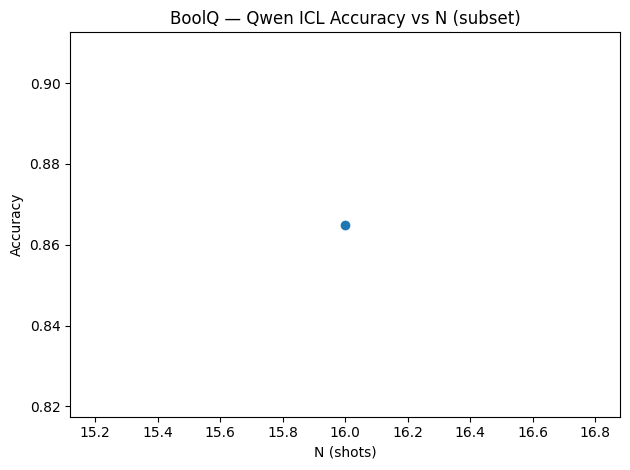

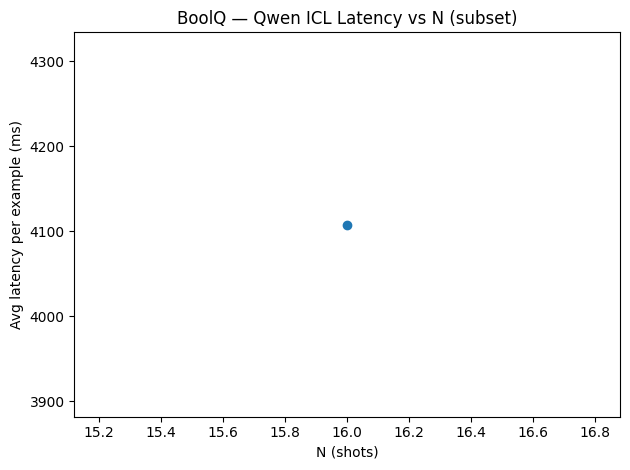

Saved to: analysis_out


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

df = pd.DataFrame(results).sort_values("N")

PLOT_DIR = Path("analysis_out")
PLOT_DIR.mkdir(exist_ok=True)

# Accuracy vs N
plt.figure()
plt.plot(df["N"], df["accuracy"], marker="o")
plt.xlabel("N (shots)")
plt.ylabel("Accuracy")
plt.title("BoolQ — Qwen ICL Accuracy vs N (subset)")
plt.tight_layout()
plt.savefig(PLOT_DIR / "boolq_qwen_icl_accuracy_vs_N.png", dpi=200)
plt.show()

# Latency vs N
plt.figure()
plt.plot(df["N"], df["avg_latency_ms"], marker="o")
plt.xlabel("N (shots)")
plt.ylabel("Avg latency per example (ms)")
plt.title("BoolQ — Qwen ICL Latency vs N (subset)")
plt.tight_layout()
plt.savefig(PLOT_DIR / "boolq_qwen_icl_latency_vs_N.png", dpi=200)
plt.show()

df.to_csv(PLOT_DIR / "boolq_qwen_icl_summary.csv", index=False)
print("Saved to:", PLOT_DIR)

In [14]:
Ns = [16, 32, 64, 128, 256]
results = []

for N in Ns:
    demos = read_jsonl(SPLIT_DIR / f"N{N}_seed{seed}.jsonl")

    preds, golds, latencies = [], [], []

    for row in eval_rows[:200]:  # start small
        prompt = build_prompt(demos, row["passage"], row["question"])
        raw, _, lat = run_one(prompt)

        preds.append(parse_pred(raw))
        golds.append(gold_label_boolq(row))
        latencies.append(lat)

    acc = sum(p == g for p, g in zip(preds, golds)) / len(golds)
    avg_lat = sum(latencies) / len(latencies)

    results.append({
        "N": N,
        "accuracy": acc,
        "avg_latency_ms": avg_lat
    })

    print(f"N={N} | Acc={acc:.3f} | Lat={avg_lat:.1f}ms")

KeyboardInterrupt: 